In [116]:
# https://judge.nitro-ai.org/competitions/nitro/pre-iaio-2026/1/view

import json
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error as rmse
from tqdm.auto import tqdm

# 1. Load the raw numbers
with open("/kaggle/input/datasets/abukanabek/preiaio-2026-1/model_params.json", "r") as f:
    params = json.load(f)

# 2. Create a brand new, empty pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# 3. Inject the "params" back into the components
pipe.named_steps['scaler'].mean_ = np.array(params["scaler_mean"])
pipe.named_steps['scaler'].var_ = np.array(params["scaler_var"])
pipe.named_steps['scaler'].scale_ = np.array(params["scaler_scale"])
pipe.named_steps['scaler'].n_features_in_ = len(params["scaler_mean"])

pipe.named_steps['regressor'].coef_ = np.array(params["coef"])
pipe.named_steps['regressor'].intercept_ = params["intercept"]

print("Pipeline reconstructed successfully!")

pipe

Pipeline reconstructed successfully!


Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [117]:
import pandas as pd

train = pd.read_csv('/kaggle/input/datasets/abukanabek/preiaio-2026-1/train_data.csv')

print(train.shape)

train.head()

(500, 13)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,target,datapointID,subtaskID
0,38.386698,96.119755,74.799984,60.720818,17.224338,16.089440,7.296285,88.208061,60.737244,71.793142,-3.316884,0,1
1,7.509907,103.118333,92.599548,26.231124,27.665694,21.204378,39.120991,61.771641,46.851906,34.885306,-14.268649,1,1
2,57.722605,10.057386,23.272128,33.462029,39.583413,76.698472,14.443321,45.518765,56.918328,0.984856,-20.099994,2,1
3,62.298347,18.787687,9.154591,96.303772,99.248860,81.650804,32.924315,12.399853,69.459085,45.647168,-11.175629,3,1
4,14.072725,51.618305,6.646087,92.645215,29.129085,67.234057,34.152586,55.193712,55.924881,20.460944,-21.376248,4,1


In [118]:
mu = np.array(params['scaler_mean'])
std = np.array(params['scaler_var']) ** 0.5
w = np.array(params['coef'])
b = np.array(params['intercept'])

mu.shape, std.shape, w.shape, b.shape

((10,), (10,), (10,), ())

In [119]:
# x_clean * w_plane.T + b_plane = 0

def reconstruct(x_noisy, y):
    w_plane = w / std
    b_plane = -y + b - mu @ (w / std)

    dist = (x_noisy @ w_plane + b_plane) / np.linalg.norm(w_plane, ord=2)
    x_clean = x_noisy - w_plane * (dist / np.linalg.norm(w_plane, ord=2))
    return x_clean

In [120]:
X_clean = np.zeros((train.shape[0], 10))

for i, row in train.iterrows():
    x_noisy = row[[f'f{j}' for j in range(1, 10+1)]].values
    y = row['target']

    x_clean = reconstruct(x_noisy, y)
    X_clean[i] = x_clean

X_clean

array([[37.44786798, 95.10559517, 73.17429183, ..., 86.59718959,
        60.12330467, 70.80034806],
       [ 2.02253894, 97.19067343, 83.09754338, ..., 52.35626117,
        43.26349208, 29.08252739],
       [61.20809928, 13.82254709, 29.30765966, ..., 51.4992735 ,
        59.19763533,  4.67069426],
       ...,
       [47.49063546, 89.90339186, 52.42567648, ..., 20.53351423,
         0.13160958,  3.90468858],
       [97.706996  , 24.35429282, 66.24369217, ..., 59.95404367,
        73.16614571, 76.95061023],
       [97.5744183 , 57.17070264, 34.30049931, ..., 32.89525842,
        81.51040641, 59.76878027]])

<Axes: >

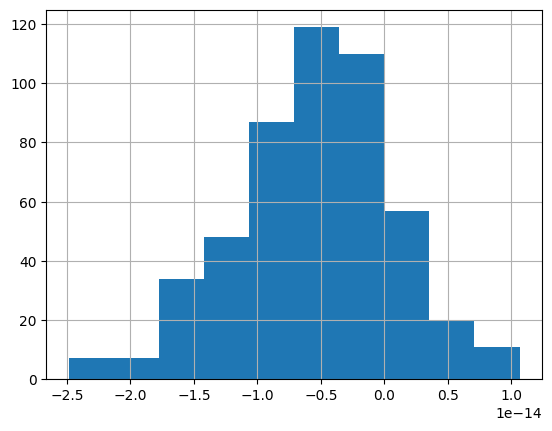

In [121]:
(pipe.predict(X_clean) - train['target']).hist()

In [122]:
subm = pd.read_csv("/kaggle/input/datasets/abukanabek/preiaio-2026-1/sample_output.csv")
subm['answer'] = pd.DataFrame(X_clean).apply(lambda row: ','.join([str(p) for p in row.tolist()]), axis=1)
subm.to_csv("submission.csv", index=False)
subm.head()

,datapointID,subtaskID,answer
0,0,1,"37.447867981456604,95.10559516879619,73.174291..."
1,1,1,"2.022538936349089,97.19067342557233,83.0975433..."
2,2,1,"61.20809928312291,13.822547086345427,29.307659..."
3,3,1,"60.744315281076744,17.1089643887202,6.46360776..."
4,4,1,"12.191512432492267,49.586149328050794,3.388552..."
